In [1]:
from matplotlib import pyplot as plt
from dataclasses import dataclass
import json
from pathlib import Path
from scripts.common import (
    BenchMatrix,
    Tool,
    get_matrix_base_name,
    get_matrix_filename_mtx,
)
import yaml
import math
import numpy as np


In [2]:
@dataclass
class Results:
    fsharp_results: dict
    inpla_results: dict
    lagraph_results: dict
    networkx_results: dict
    vine_results: dict

In [3]:
def load_results(raw_results_path: Path) -> Results:
    try:
        fsharp_results_json = sorted(
            raw_results_path.glob("*_fsharp.json"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        with open(fsharp_results_json, "r", encoding="utf-8") as f:
            fsharp_results = json.load(f)
            print("Read", fsharp_results_json)
    except FileNotFoundError:
        print("QTreeFSharp results weren't found")
        fsharp_results = dict()

    try:
        inpla_results_json = sorted(
            raw_results_path.glob("*_inpla.json"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        with open(inpla_results_json, "r", encoding="utf-8") as f:
            inpla_results = json.load(f)
            print("Read", inpla_results_json)
    except FileNotFoundError:
        print("Inpla results weren't found")
        inpla_results = dict()

    try:
        lagraph_results_json = sorted(
            raw_results_path.glob("*_lagraph.json"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        with open(lagraph_results_json, "r", encoding="utf-8") as f:
            lagraph_results = json.load(f)
            print("Read", lagraph_results_json)
    except FileNotFoundError:
        print("LAGraph results weren't found")
        lagraph_results = dict()

    try:
        networkx_results_json = sorted(
            raw_results_path.glob("*_networkx.json"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        with open(networkx_results_json, "r", encoding="utf-8") as f:
            networkx_results = json.load(f)
            print("Read", networkx_results_json)
    except FileNotFoundError:
        print("QTreeFSharp results weren't found")
        networkx_results = dict()

    try:
        vine_results_json = sorted(
            raw_results_path.glob("*_vine.json"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        with open(vine_results_json, "r", encoding="utf-8") as f:
            vine_results = json.load(f)
            print("Read", vine_results_json)
    except FileNotFoundError:
        print("QTreeVine results weren't found")
        vine_results = dict()

    return Results(
        fsharp_results, inpla_results, lagraph_results, networkx_results, vine_results
    )

In [4]:
results = load_results(Path("results") / "raw")

Read results/raw/2026-04-28T19:45+03:00_fsharp.json
Read results/raw/2026-04-30T10_28+03_00_inpla.json
Read results/raw/2026-04-29T14:16+03:00_lagraph.json
Read results/raw/2026-04-29T14:00+03:00_networkx.json
Read results/raw/20260429_085711_vine.json


In [5]:
with open(Path("matrices.yaml"), "r", encoding="utf-8") as m_file:
    matrices: list[BenchMatrix] = yaml.safe_load(m_file)
enabled_matrices = filter(lambda matrix: matrix["enabled"], matrices)

In [6]:
thread_counts = [1] + list(range(2, 16 + 1, 2))

In [7]:
def get_inpla_time(result: str) -> float:
    if "Error".casefold() in result.casefold():
        return math.nan
    return float(result.splitlines()[-1].split(" ")[-2])


def get_vine_time(result: str) -> float:
    return float(result.split(" ")[-2])


def get_lagraph_time(result: str) -> float:
    return float(result.splitlines()[-1].split(" ")[-2])

In [8]:
def get_inpla_results(results: Results, algorithm: str, matrix: str) -> tuple[np.ndarray, np.ndarray]:
    benchmark_result = results.inpla_results[algorithm][matrix]
    time = []
    error = []
    for thread_count in thread_counts:
        times = list(map(get_inpla_time, benchmark_result[str(thread_count)]))
        time.append(np.nanmean(times))
        error.append(np.nanstd(times))
    return (np.array(time), np.array(error))

def get_lagraph_results(results: Results, algorithm: str, matrix: str) -> tuple[np.ndarray, np.ndarray]:
    benchmark_result = results.lagraph_results[algorithm][matrix]
    time = []
    error = []
    for thread_count in thread_counts:
        times = list(map(get_lagraph_time, benchmark_result[str(thread_count)]))
        time.append(np.mean(times))
        error.append(np.std(times))
    return (np.array(time), np.array(error))

def get_fsharp_results(results: Results, algorithm: str, matrix: str) -> tuple[np.ndarray, np.ndarray]:
    benchmark_results =   list(
        filter(
            lambda res: (
                matrix.casefold() in res["FullName"].casefold()
            ),
            results.fsharp_results[algorithm]["Benchmarks"],
        )
    )[0]
    time = np.array([benchmark_results["Statistics"]["Mean"] / 1e9] * len(thread_counts))
    error = np.array([benchmark_results["Statistics"]["StandardDeviation"] / 1e9] * len(thread_counts))
    return time, error

def get_networkx_results(results: Results, algorithm: str, matrix: str) -> tuple[np.ndarray, np.ndarray]:
    benchmark_results = list(
        filter(
            lambda res: (
                res["extra_info"]["algorithm"] == algorithm
                and res["extra_info"]["graph_name"] == matrix
            ),
            results.networkx_results["benchmarks"],
        )
    )[0]
    time = np.array([benchmark_results["stats"]["mean"]] * len(thread_counts))
    error = np.array([benchmark_results["stats"]["stddev"]] * len(thread_counts))
    return time, error

def get_vine_results(results: Results, algorithm: str, matrix: str) -> tuple[np.ndarray, np.ndarray]:
    benchmark_result = results.vine_results[algorithm][matrix]
    time = []
    error = []
    for thread_count in thread_counts:
        times = list(map(get_vine_time, benchmark_result[str(thread_count)]))
        time.append(np.mean(times))
        error.append(np.std(times))
    return (np.array(time), np.array(error))

# Для coAuthor. Построить для lagraph  и inpla ускорение (относительно одного потока)

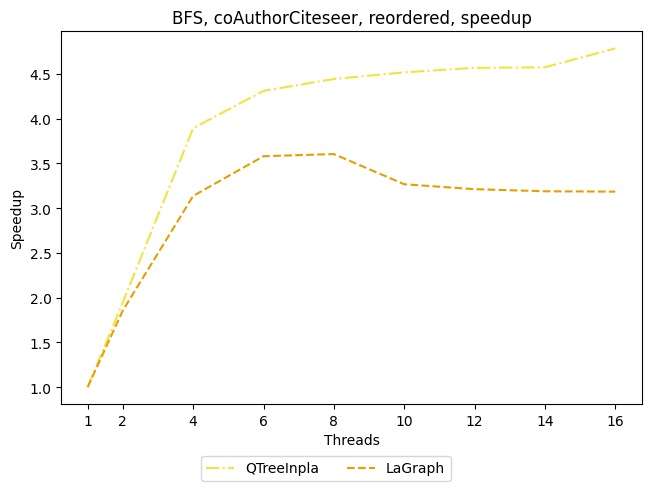

In [9]:
(coAuthor_inpla_times, _) = get_inpla_results(results, "bfs","coAuthorsCiteseer_reordered")
(coAuthor_lagraph_times, _) = get_lagraph_results(results, "bfs","coAuthorsCiteseer_reordered")

coAuthor_inpla_speedup = coAuthor_inpla_times[0] / coAuthor_inpla_times
coAuthor_lagraph_speedup = coAuthor_lagraph_times[0] / coAuthor_lagraph_times

fig, ax = plt.subplots(layout="constrained")
ax.set_title("BFS, coAuthorCiteseer, reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    coAuthor_inpla_speedup,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    coAuthor_lagraph_speedup,
    color="#E69F00",
    linestyle="--",
    label="LaGraph",
)
fig.legend(loc="outside lower center", ncols=2)

# Для bone и usroads собрать всё (кроме lagraph и networkx) на один график. 


In [10]:
(usroads_inpla_times, usroads_inpla_error) = get_inpla_results(results, "bfs", "usroads-48")
(usroads_reord_inpla_times, usroads_reord_inpla_error) = get_inpla_results(results, "bfs", "usroads-48_reordered")


usroads_fsharp_times, usroads_fsharp_error = get_fsharp_results(results, "bfs", "usroads-48")
usroads_reord_fsharp_times, usroads_reord_fsharp_error = get_fsharp_results(results, "bfs", "usroads-48_reordered")

In [11]:
bone_inpla_times, bone_inpla_error = get_inpla_results(results, "bfs", "boneS01")
bone_reord_inpla_times, bone_reord_inpla_error = get_inpla_results(results, "bfs", "boneS01_reordered")

bone_fsharp_times, bone_fsharp_error = get_fsharp_results(results, "bfs", "boneS01")
bone_reord_fsharp_times, bone_reord_fsharp_error = get_fsharp_results(results, "bfs", "boneS01_reordered")

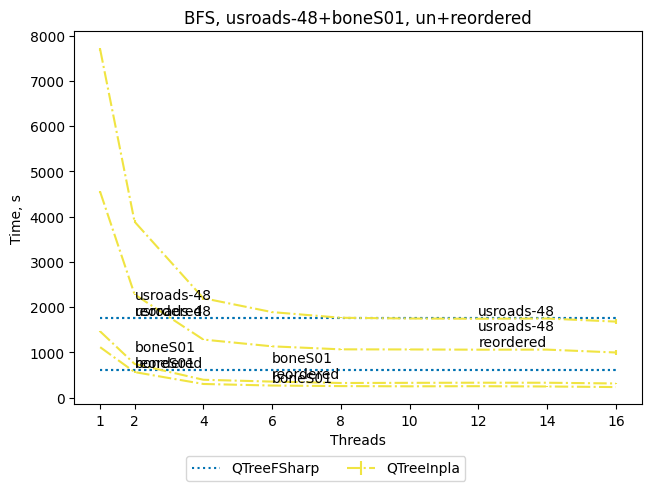

In [12]:

fig, ax = plt.subplots(layout="constrained")
ax.set_title("BFS, usroads-48+boneS01, un+reordered")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Time, s")

# usroads
ax.errorbar(
    thread_counts,
    usroads_inpla_times,
    yerr=usroads_inpla_error,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.text(
    thread_counts[-3],
    usroads_inpla_times[-3] + usroads_inpla_error[-3] + 5,
    "usroads-48",
    va="bottom",
)
ax.errorbar(
    thread_counts,
    usroads_reord_inpla_times,
    yerr=usroads_reord_inpla_error,
    color="#F0E442",
    linestyle="-.",
)
ax.text(
    thread_counts[-3],
    usroads_reord_inpla_times[-3] + usroads_reord_inpla_error[-3] + 5,
    "usroads-48\nreordered",
    va="bottom",
)
ax.plot(
    thread_counts,
    usroads_fsharp_times,
    color="#0072B2",
    linestyle=":",
    label="QTreeFSharp",
)
ax.text(
    thread_counts[1],
    usroads_fsharp_times[1] + usroads_fsharp_error[1] + 5,
    "usroads-48",
    va="bottom",
)
ax.plot(
    thread_counts,
    usroads_reord_fsharp_times,
    color="#0072B2",
    linestyle=":",
)
ax.text(
    thread_counts[1],
    usroads_reord_fsharp_times[1] + usroads_reord_fsharp_error[1] + 5,
    "usroads-48\nreordered",
    va="bottom",
)
# bone
ax.errorbar(
    thread_counts,
    bone_inpla_times,
    yerr=bone_inpla_error,
    color="#F0E442",
    linestyle="-.",
)
ax.text(
    thread_counts[-6],
    bone_inpla_times[-6] + bone_inpla_error[-6] + 5,
    "boneS01",
    va="bottom",
)
ax.errorbar(
    thread_counts,
    bone_reord_inpla_times,
    yerr=bone_reord_inpla_error,
    color="#F0E442",
    linestyle="-.",
)
ax.text(
    thread_counts[-6],
    bone_reord_inpla_times[-6] + bone_reord_inpla_error[-6] + 5,
    "boneS01\nreordered",
    va="bottom",
)
ax.plot(
    thread_counts,
    bone_fsharp_times,
    color="#0072B2",
    linestyle=":",
)
ax.text(
    thread_counts[1],
    bone_fsharp_times[1] + bone_fsharp_error[1] + 5,
    "boneS01",
    va="bottom",
)
ax.plot(
    thread_counts,
    bone_reord_fsharp_times,
    color="#0072B2",
    linestyle=":",
)
ax.text(
    thread_counts[1],
    bone_reord_fsharp_times[1] + bone_reord_fsharp_error[1] + 5,
    "boneS01\nreordered",
    va="bottom",
)
fig.legend(loc="outside lower center", ncols=2)


## Попробовать для этих ребят тоже ускорение построить. 

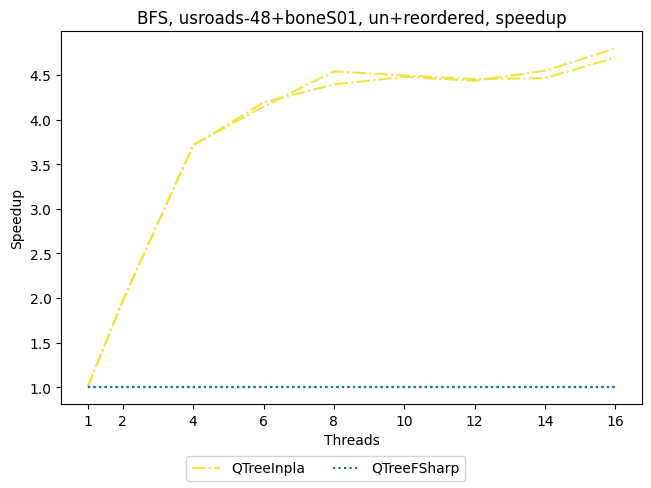

In [13]:
bone_inpla_speedup = bone_inpla_times[0] / bone_inpla_times
bone_fsharp_speedup = bone_fsharp_times[0] / bone_fsharp_times
bone_reord_inpla_speedup = bone_reord_inpla_times[0] / bone_reord_inpla_times
bone_reord_fsharp_speedup = bone_reord_fsharp_times[0] / bone_reord_fsharp_times


fig, ax = plt.subplots(layout="constrained")
ax.set_title("BFS, usroads-48+boneS01, un+reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    bone_inpla_speedup,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    bone_fsharp_speedup,
        color="#0072B2",
        linestyle=":",
        label="QTreeFSharp",
)
ax.plot(
    thread_counts,
    bone_reord_inpla_speedup,
    color="#F0E442",
    linestyle="-.",
)
ax.plot(
    thread_counts,
    bone_reord_fsharp_speedup,
        color="#0072B2",
        linestyle=":",
)
fig.legend(loc="outside lower center", ncols=2)

# Для trefethen для всех попробовать нарисовать отношение времени bfs к sssp. Идея: оценить "расходы на арифметику" при одинаковой структуре вычислений.

In [14]:
(trefethen_bfs_inpla_times, trefethen_bfs_inpla_error) = get_inpla_results(results, "bfs", "Trefethen_2000")
(trefethen_reord_bfs_inpla_times, trefethen_reord_bfs_inpla_error) = get_inpla_results(results, "bfs", "Trefethen_2000_reordered")

(trefethen_bfs_fsharp_times, trefethen_bfs_fsharp_error) = get_fsharp_results(results, "bfs", "Trefethen_2000")
(trefethen_reord_bfs_fsharp_times, trefethen_reord_bfs_fsharp_error) = get_fsharp_results(results, "bfs", "Trefethen_2000_reordered")

(trefethen_bfs_lagraph_times, trefethen_bfs_lagraph_error) = get_lagraph_results(results, "bfs", "Trefethen_2000")
(trefethen_reord_bfs_lagraph_times, trefethen_reord_bfs_lagraph_error) = get_lagraph_results(results, "bfs", "Trefethen_2000_reordered")

(trefethen_bfs_networkx_times, trefethen_bfs_networkx_error) = get_networkx_results(results, "bfs", "Trefethen_2000")
(trefethen_reord_bfs_networkx_times, trefethen_reord_bfs_networkx_error) = get_networkx_results(results, "bfs", "Trefethen_2000_reordered")

(trefethen_bfs_vine_times, trefethen_bfs_vine_error) = get_vine_results(results, "bfs", "Trefethen_2000")
(trefethen_reord_bfs_vine_times, trefethen_reord_bfs_vine_error) = get_vine_results(results, "bfs", "Trefethen_2000_reordered")

In [15]:
(trefethen_sssp_inpla_times, trefethen_sssp_inpla_error) = get_inpla_results(results, "sssp", "Trefethen_2000")
(trefethen_reord_sssp_inpla_times, trefethen_reord_sssp_inpla_error) = get_inpla_results(results, "sssp", "Trefethen_2000_reordered")

(trefethen_sssp_fsharp_times, trefethen_sssp_fsharp_error) = get_fsharp_results(results, "sssp", "Trefethen_2000")
(trefethen_reord_sssp_fsharp_times, trefethen_reord_sssp_fsharp_error) = get_fsharp_results(results, "sssp", "Trefethen_2000_reordered")

(trefethen_sssp_lagraph_times, trefethen_sssp_lagraph_error) = get_lagraph_results(results, "sssp", "Trefethen_2000")
(trefethen_reord_sssp_lagraph_times, trefethen_reord_sssp_lagraph_error) = get_lagraph_results(results, "sssp", "Trefethen_2000_reordered")

(trefethen_sssp_networkx_times, trefethen_sssp_networkx_error) = get_networkx_results(results, "sssp", "Trefethen_2000")
(trefethen_reord_sssp_networkx_times, trefethen_reord_sssp_networkx_error) = get_networkx_results(results, "sssp", "Trefethen_2000_reordered")

(trefethen_sssp_vine_times, trefethen_sssp_vine_error) = get_vine_results(results, "sssp", "Trefethen_2000")
(trefethen_reord_sssp_vine_times, trefethen_reord_sssp_vine_error) = get_vine_results(results, "sssp", "Trefethen_2000_reordered")

## Unreordered

In [16]:
trefethen_inpla_ratio = trefethen_bfs_inpla_times / trefethen_sssp_inpla_times
trefethen_fsharp_ratio = trefethen_bfs_fsharp_times / trefethen_sssp_fsharp_times
trefethen_lagraph_ratio = trefethen_bfs_lagraph_times / trefethen_sssp_lagraph_times
trefethen_networkx_ratio = trefethen_bfs_networkx_times / trefethen_sssp_networkx_times
trefethen_vine_ratio = trefethen_bfs_vine_times / trefethen_sssp_vine_times

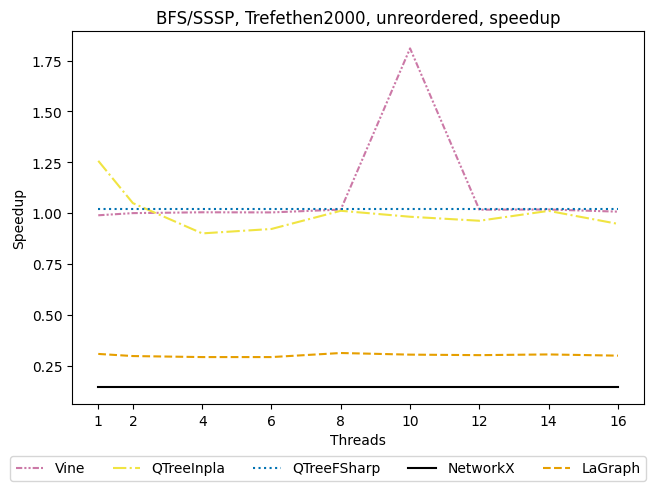

In [17]:
fig, ax = plt.subplots(layout="constrained")
ax.set_title("BFS/SSSP, Trefethen2000, unreordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    trefethen_vine_ratio,
    color="#CC79A7",
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="Vine",
)
ax.plot(
    thread_counts,
    trefethen_inpla_ratio,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    trefethen_fsharp_ratio,
    color="#0072B2",
    linestyle=":",
    label="QTreeFSharp",
)
ax.plot(
    thread_counts,
    trefethen_networkx_ratio,
    color="#000000",
    linestyle="-",
    label="NetworkX",
)
ax.plot(
    thread_counts,
    trefethen_lagraph_ratio,
    color="#E69F00",
    linestyle="--",
    label="LaGraph",
)

fig.legend(loc="outside lower center", ncols=5)

## Reordered

In [18]:
trefethen_reord_inpla_ratio = trefethen_reord_bfs_inpla_times / trefethen_reord_sssp_inpla_times
trefethen_reord_fsharp_ratio = trefethen_reord_bfs_fsharp_times / trefethen_reord_sssp_fsharp_times
trefethen_reord_lagraph_ratio = trefethen_reord_bfs_lagraph_times / trefethen_reord_sssp_lagraph_times
trefethen_reord_networkx_ratio = trefethen_reord_bfs_networkx_times / trefethen_reord_sssp_networkx_times
trefethen_reord_vine_ratio = trefethen_reord_bfs_vine_times / trefethen_reord_sssp_vine_times


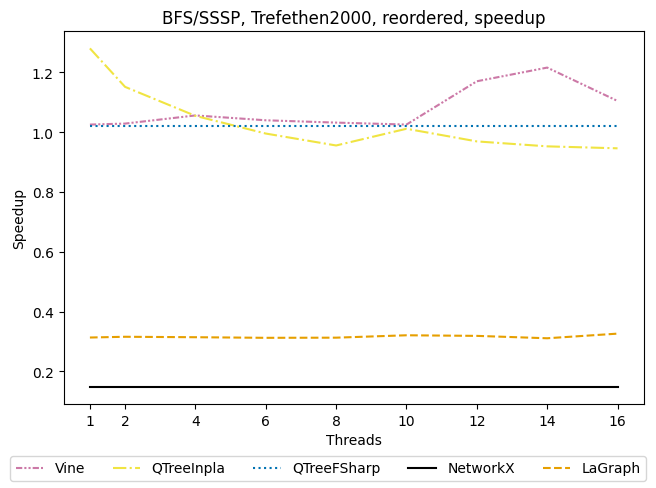

In [19]:
fig, ax = plt.subplots(layout="constrained")
ax.set_title("BFS/SSSP, Trefethen2000, reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    trefethen_reord_vine_ratio,
    color="#CC79A7",
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="Vine",
)
ax.plot(
    thread_counts,
    trefethen_reord_inpla_ratio,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    trefethen_reord_fsharp_ratio,
    color="#0072B2",
    linestyle=":",
    label="QTreeFSharp",
)
ax.plot(
    thread_counts,
    trefethen_reord_networkx_ratio,
    color="#000000",
    linestyle="-",
    label="NetworkX",
)
ax.plot(
    thread_counts,
    trefethen_reord_lagraph_ratio,
    color="#E69F00",
    linestyle="--",
    label="LaGraph",
)

fig.legend(loc="outside lower center", ncols=5)

# Для gr_30 и для trefethen и, видимо, andrews построить отношение обычной и переупорядоченной для всех алгоритмов.

## Trefethen переупорядоченная используется только для BFS и SSSP

In [20]:
trefethen_un_reord_bfs_inpla_ratio = trefethen_bfs_inpla_times / trefethen_reord_bfs_inpla_times
trefethen_un_reord_bfs_fsharp_ratio = trefethen_bfs_fsharp_times / trefethen_reord_bfs_fsharp_times
trefethen_un_reord_bfs_networkx_ratio = trefethen_bfs_networkx_times / trefethen_reord_bfs_networkx_times
trefethen_un_reord_bfs_lagraph_ratio = trefethen_bfs_lagraph_times / trefethen_reord_bfs_lagraph_times
trefethen_un_reord_bfs_vine_ratio = trefethen_bfs_vine_times / trefethen_reord_bfs_vine_times

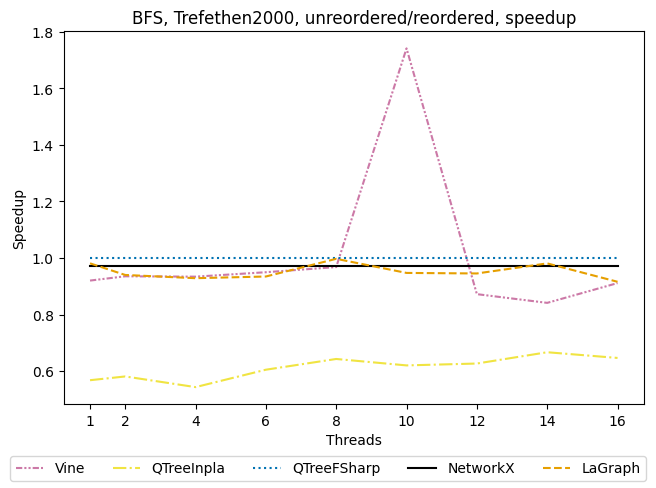

In [21]:
fig, ax = plt.subplots(layout="constrained")
ax.set_title("BFS, Trefethen2000, unreordered/reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    trefethen_un_reord_bfs_vine_ratio,
    color="#CC79A7",
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="Vine",
)
ax.plot(
    thread_counts,
    trefethen_un_reord_bfs_inpla_ratio,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    trefethen_un_reord_bfs_fsharp_ratio,
    color="#0072B2",
    linestyle=":",
    label="QTreeFSharp",
)
ax.plot(
    thread_counts,
    trefethen_un_reord_bfs_networkx_ratio,
    color="#000000",
    linestyle="-",
    label="NetworkX",
)
ax.plot(
    thread_counts,
    trefethen_un_reord_bfs_lagraph_ratio,
    color="#E69F00",
    linestyle="--",
    label="LaGraph",
)

fig.legend(loc="outside lower center", ncols=5)

In [22]:
trefethen_un_reord_sssp_inpla_ratio = trefethen_sssp_inpla_times / trefethen_reord_sssp_inpla_times
trefethen_un_reord_sssp_fsharp_ratio = trefethen_sssp_fsharp_times / trefethen_reord_sssp_fsharp_times
trefethen_un_reord_sssp_networkx_ratio = trefethen_sssp_networkx_times / trefethen_reord_sssp_networkx_times
trefethen_un_reord_sssp_lagraph_ratio = trefethen_sssp_lagraph_times / trefethen_reord_sssp_lagraph_times
trefethen_un_reord_sssp_vine_ratio = trefethen_sssp_vine_times / trefethen_reord_sssp_vine_times

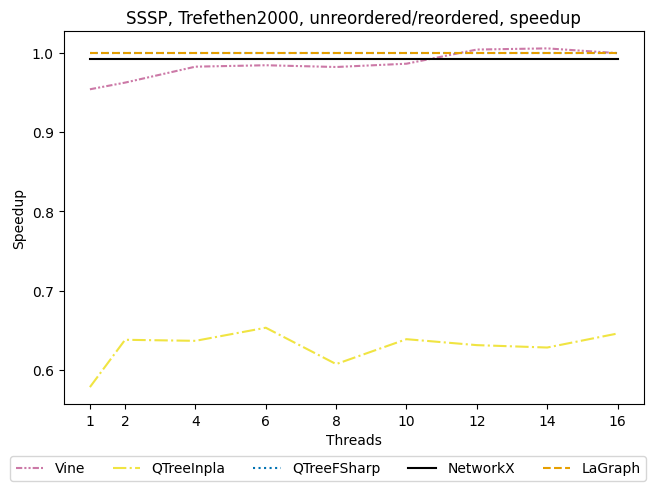

In [23]:
fig, ax = plt.subplots(layout="constrained")
ax.set_title("SSSP, Trefethen2000, unreordered/reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    trefethen_un_reord_sssp_vine_ratio,
    color="#CC79A7",
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="Vine",
)
ax.plot(
    thread_counts,
    trefethen_un_reord_sssp_inpla_ratio,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    trefethen_un_reord_sssp_fsharp_ratio,
    color="#0072B2",
    linestyle=":",
    label="QTreeFSharp",
)
ax.plot(
    thread_counts,
    trefethen_un_reord_sssp_networkx_ratio,
    color="#000000",
    linestyle="-",
    label="NetworkX",
)
ax.plot(
    thread_counts,
    trefethen_un_reord_sssp_lagraph_ratio,
    color="#E69F00",
    linestyle="--",
    label="LaGraph",
)

fig.legend(loc="outside lower center", ncols=5)

## gr_30_30

In [24]:
(gr_bfs_inpla_times, gr_bfs_inpla_error) = get_inpla_results(results, "bfs", "gr_30_30")
(gr_reord_bfs_inpla_times, gr_reord_bfs_inpla_error) = get_inpla_results(results, "bfs", "gr_30_30_reordered")

(gr_bfs_fsharp_times, gr_bfs_fsharp_error) = get_fsharp_results(results, "bfs", "gr_30_30")
(gr_reord_bfs_fsharp_times, gr_reord_bfs_fsharp_error) = get_fsharp_results(results, "bfs", "gr_30_30_reordered")

(gr_bfs_lagraph_times, gr_bfs_lagraph_error) = get_lagraph_results(results, "bfs", "gr_30_30")
(gr_reord_bfs_lagraph_times, gr_reord_bfs_lagraph_error) = get_lagraph_results(results, "bfs", "gr_30_30_reordered")

(gr_bfs_networkx_times, gr_bfs_networkx_error) = get_networkx_results(results, "bfs", "gr_30_30")
(gr_reord_bfs_networkx_times, gr_reord_bfs_networkx_error) = get_networkx_results(results, "bfs", "gr_30_30_reordered")

(gr_bfs_vine_times, gr_bfs_vine_error) = get_vine_results(results, "bfs", "gr_30_30")
(gr_reord_bfs_vine_times, gr_reord_bfs_vine_error) = get_vine_results(results, "bfs", "gr_30_30_reordered")

In [25]:
gr_un_reord_bfs_inpla_ratio = gr_bfs_inpla_times / gr_reord_bfs_inpla_times
gr_un_reord_bfs_fsharp_ratio = gr_bfs_fsharp_times / gr_reord_bfs_fsharp_times
gr_un_reord_bfs_networkx_ratio = gr_bfs_networkx_times / gr_reord_bfs_networkx_times
gr_un_reord_bfs_lagraph_ratio = gr_bfs_lagraph_times / gr_reord_bfs_lagraph_times
gr_un_reord_bfs_vine_ratio = gr_bfs_vine_times / gr_reord_bfs_vine_times

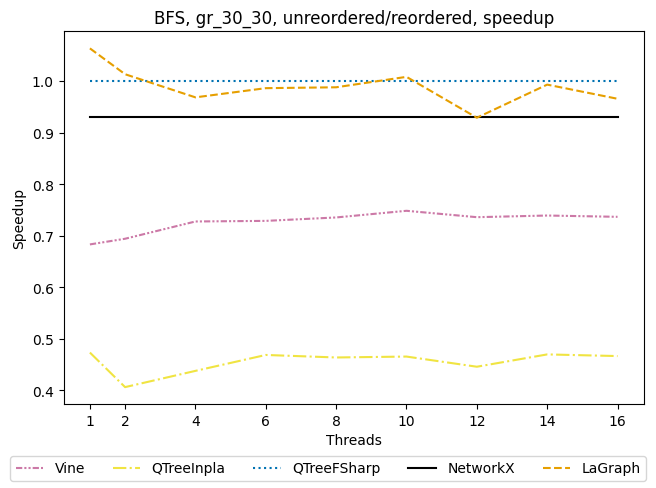

In [26]:
fig, ax = plt.subplots(layout="constrained")
ax.set_title("BFS, gr_30_30, unreordered/reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    gr_un_reord_bfs_vine_ratio,
    color="#CC79A7",
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="Vine",
)
ax.plot(
    thread_counts,
    gr_un_reord_bfs_inpla_ratio,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    gr_un_reord_bfs_fsharp_ratio,
    color="#0072B2",
    linestyle=":",
    label="QTreeFSharp",
)
ax.plot(
    thread_counts,
    gr_un_reord_bfs_networkx_ratio,
    color="#000000",
    linestyle="-",
    label="NetworkX",
)
ax.plot(
    thread_counts,
    gr_un_reord_bfs_lagraph_ratio,
    color="#E69F00",
    linestyle="--",
    label="LaGraph",
)

fig.legend(loc="outside lower center", ncols=5)

In [27]:
(gr_sssp_inpla_times, gr_sssp_inpla_error) = get_inpla_results(results, "sssp", "gr_30_30")
(gr_reord_sssp_inpla_times, gr_reord_sssp_inpla_error) = get_inpla_results(results, "sssp", "gr_30_30_reordered")

(gr_sssp_fsharp_times, gr_sssp_fsharp_error) = get_fsharp_results(results, "sssp", "gr_30_30")
(gr_reord_sssp_fsharp_times, gr_reord_sssp_fsharp_error) = get_fsharp_results(results, "sssp", "gr_30_30_reordered")

(gr_sssp_lagraph_times, gr_sssp_lagraph_error) = get_lagraph_results(results, "sssp", "gr_30_30")
(gr_reord_sssp_lagraph_times, gr_reord_sssp_lagraph_error) = get_lagraph_results(results, "sssp", "gr_30_30_reordered")

(gr_sssp_networkx_times, gr_sssp_networkx_error) = get_networkx_results(results, "sssp", "gr_30_30")
(gr_reord_sssp_networkx_times, gr_reord_sssp_networkx_error) = get_networkx_results(results, "sssp", "gr_30_30_reordered")

(gr_sssp_vine_times, gr_sssp_vine_error) = get_vine_results(results, "sssp", "gr_30_30")
(gr_reord_sssp_vine_times, gr_reord_sssp_vine_error) = get_vine_results(results, "sssp", "gr_30_30_reordered")

In [28]:
gr_un_reord_sssp_inpla_ratio = gr_sssp_inpla_times / gr_reord_sssp_inpla_times
gr_un_reord_sssp_fsharp_ratio = gr_sssp_fsharp_times / gr_reord_sssp_fsharp_times
gr_un_reord_sssp_networkx_ratio = gr_sssp_networkx_times / gr_reord_sssp_networkx_times
gr_un_reord_sssp_lagraph_ratio = gr_sssp_lagraph_times / gr_reord_sssp_lagraph_times
gr_un_reord_sssp_vine_ratio = gr_sssp_vine_times / gr_reord_sssp_vine_times

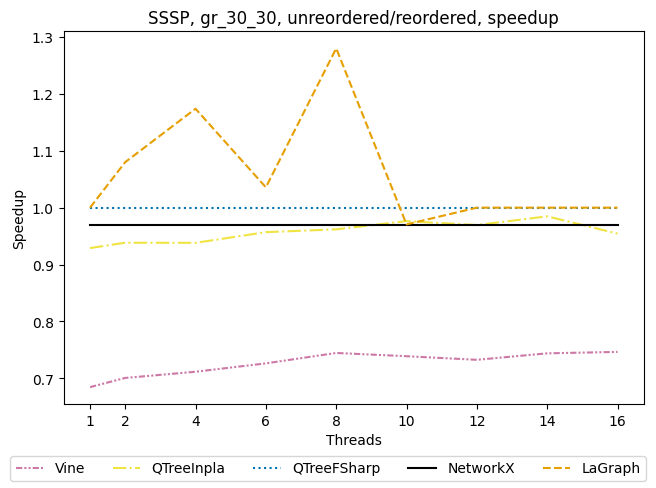

In [29]:
fig, ax = plt.subplots(layout="constrained")
ax.set_title("SSSP, gr_30_30, unreordered/reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    gr_un_reord_sssp_vine_ratio,
    color="#CC79A7",
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="Vine",
)
ax.plot(
    thread_counts,
    gr_un_reord_sssp_inpla_ratio,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    gr_un_reord_sssp_fsharp_ratio,
    color="#0072B2",
    linestyle=":",
    label="QTreeFSharp",
)
ax.plot(
    thread_counts,
    gr_un_reord_sssp_networkx_ratio,
    color="#000000",
    linestyle="-",
    label="NetworkX",
)
ax.plot(
    thread_counts,
    gr_un_reord_sssp_lagraph_ratio,
    color="#E69F00",
    linestyle="--",
    label="LaGraph",
)

fig.legend(loc="outside lower center", ncols=5)

In [30]:
(gr_tc_inpla_times, gr_tc_inpla_error) = get_inpla_results(results, "tc", "gr_30_30")
(gr_reord_tc_inpla_times, gr_reord_tc_inpla_error) = get_inpla_results(results, "tc", "gr_30_30_reordered")

(gr_tc_fsharp_times, gr_tc_fsharp_error) = get_fsharp_results(results, "tc", "gr_30_30")
(gr_reord_tc_fsharp_times, gr_reord_tc_fsharp_error) = get_fsharp_results(results, "tc", "gr_30_30_reordered")

(gr_tc_lagraph_times, gr_tc_lagraph_error) = get_lagraph_results(results, "tc", "gr_30_30")
(gr_reord_tc_lagraph_times, gr_reord_tc_lagraph_error) = get_lagraph_results(results, "tc", "gr_30_30_reordered")

(gr_tc_networkx_times, gr_tc_networkx_error) = get_networkx_results(results, "tc", "gr_30_30")
(gr_reord_tc_networkx_times, gr_reord_tc_networkx_error) = get_networkx_results(results, "tc", "gr_30_30_reordered")

(gr_tc_vine_times, gr_tc_vine_error) = get_vine_results(results, "tc", "gr_30_30")
(gr_reord_tc_vine_times, gr_reord_tc_vine_error) = get_vine_results(results, "tc", "gr_30_30_reordered")

In [31]:
gr_un_reord_tc_inpla_ratio = gr_tc_inpla_times / gr_reord_tc_inpla_times
gr_un_reord_tc_fsharp_ratio = gr_tc_fsharp_times / gr_reord_tc_fsharp_times
gr_un_reord_tc_networkx_ratio = gr_tc_networkx_times / gr_reord_tc_networkx_times
gr_un_reord_tc_lagraph_ratio = gr_tc_lagraph_times / gr_reord_tc_lagraph_times
gr_un_reord_tc_vine_ratio = gr_tc_vine_times / gr_reord_tc_vine_times

/tmp/ipykernel_141479/1477101325.py:4: RuntimeWarning: invalid value encountered in divide
  gr_un_reord_tc_lagraph_ratio = gr_tc_lagraph_times / gr_reord_tc_lagraph_times


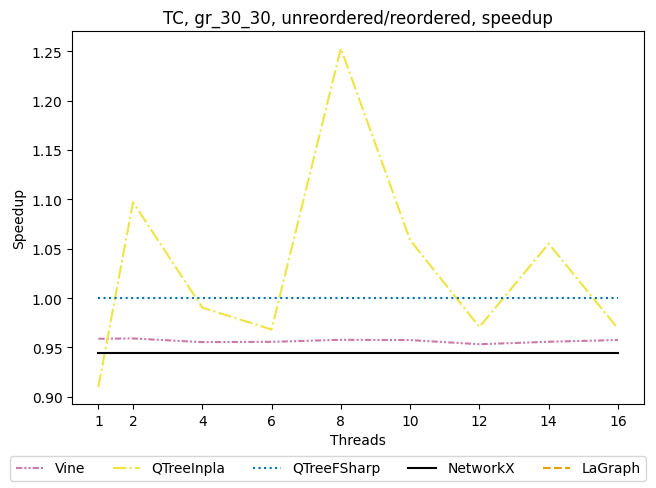

In [32]:
fig, ax = plt.subplots(layout="constrained")
ax.set_title("TC, gr_30_30, unreordered/reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

ax.plot(
    thread_counts,
    gr_un_reord_tc_vine_ratio,
    color="#CC79A7",
    linestyle=(0, (3, 1, 1, 1, 1, 1)),
    label="Vine",
)
ax.plot(
    thread_counts,
    gr_un_reord_tc_inpla_ratio,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    gr_un_reord_tc_fsharp_ratio,
    color="#0072B2",
    linestyle=":",
    label="QTreeFSharp",
)
ax.plot(
    thread_counts,
    gr_un_reord_tc_networkx_ratio,
    color="#000000",
    linestyle="-",
    label="NetworkX",
)
ax.plot(
    thread_counts,
    gr_un_reord_tc_lagraph_ratio,
    color="#E69F00",
    linestyle="--",
    label="LaGraph",
)

fig.legend(loc="outside lower center", ncols=5)

## Andrews (SSSP)

In [33]:
(andrews_sssp_inpla_times, andrews_sssp_inpla_error) = get_inpla_results(results, "sssp", "Andrews_positive")
(andrews_reord_sssp_inpla_times, andrews_reord_sssp_inpla_error) = get_inpla_results(results, "sssp", "Andrews_positive_reordered")

(andrews_sssp_fsharp_times, andrews_sssp_fsharp_error) = get_fsharp_results(results, "sssp", "Andrews_positive")
(andrews_reord_sssp_fsharp_times, andrews_reord_sssp_fsharp_error) = get_fsharp_results(results, "sssp", "Andrews_positive_reordered")

(andrews_sssp_lagraph_times, andrews_sssp_lagraph_error) = get_lagraph_results(results, "sssp", "Andrews_positive")
(andrews_reord_sssp_lagraph_times, andrews_reord_sssp_lagraph_error) = get_lagraph_results(results, "sssp", "Andrews_positive_reordered")

(andrews_sssp_networkx_times, andrews_sssp_networkx_error) = get_networkx_results(results, "sssp", "Andrews_positive")
(andrews_reord_sssp_networkx_times, andrews_reord_sssp_networkx_error) = get_networkx_results(results, "sssp", "Andrews_positive_reordered")

# (andrews_sssp_vine_times, andrews_sssp_vine_error) = get_vine_results(results, "sssp", "Andrews_positive")
# (andrews_reord_sssp_vine_times, andrews_reord_sssp_vine_error) = get_vine_results(results, "sssp", "Andrews_positive_reordered")

In [34]:
andrews_un_reord_sssp_inpla_ratio = andrews_sssp_inpla_times / andrews_reord_sssp_inpla_times
andrews_un_reord_sssp_fsharp_ratio = andrews_sssp_fsharp_times / andrews_reord_sssp_fsharp_times
andrews_un_reord_sssp_networkx_ratio = andrews_sssp_networkx_times / andrews_reord_sssp_networkx_times
andrews_un_reord_sssp_lagraph_ratio = andrews_sssp_lagraph_times / andrews_reord_sssp_lagraph_times
# andrews_un_reord_sssp_vine_ratio = andrews_sssp_vine_times / andrews_reord_sssp_vine_times

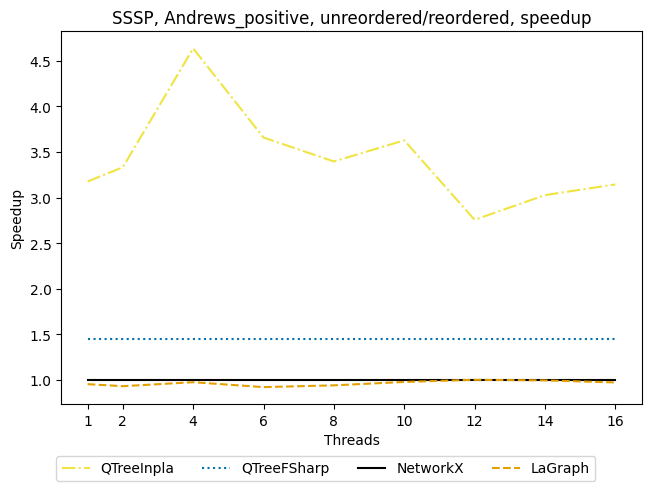

In [35]:
fig, ax = plt.subplots(layout="constrained")
ax.set_title("SSSP, Andrews_positive, unreordered/reordered, speedup")

ax.set_xticks(thread_counts)
ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")

# ax.plot(
#     thread_counts,
#     andrews_un_reord_sssp_vine_ratio,
#     color="#CC79A7",
#     linestyle=(0, (3, 1, 1, 1, 1, 1)),
#     label="Vine",
# )
ax.plot(
    thread_counts,
    andrews_un_reord_sssp_inpla_ratio,
    color="#F0E442",
    linestyle="-.",
    label="QTreeInpla",
)
ax.plot(
    thread_counts,
    andrews_un_reord_sssp_fsharp_ratio,
    color="#0072B2",
    linestyle=":",
    label="QTreeFSharp",
)
ax.plot(
    thread_counts,
    andrews_un_reord_sssp_networkx_ratio,
    color="#000000",
    linestyle="-",
    label="NetworkX",
)
ax.plot(
    thread_counts,
    andrews_un_reord_sssp_lagraph_ratio,
    color="#E69F00",
    linestyle="--",
    label="LaGraph",
)

fig.legend(loc="outside lower center", ncols=5)